In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import shap

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df = df[['Survived','Pclass','Sex','Age','Fare']]

df['Age'].fillna(df['Age'].median(), inplace=True)

df['Sex'] = df['Sex'].map({'male':0,'female':1})

df.head()

C:\Users\rutvij kudtarkar\AppData\Local\Temp\ipykernel_4520\3605617349.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [5]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


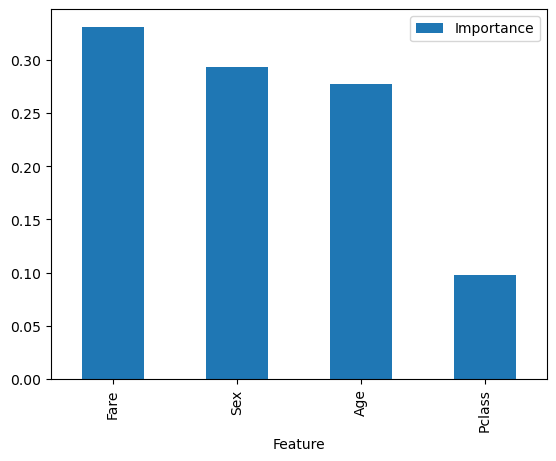

In [9]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.show()

In [10]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

In [12]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print(np.array(shap_values).shape)

(179, 4, 2)


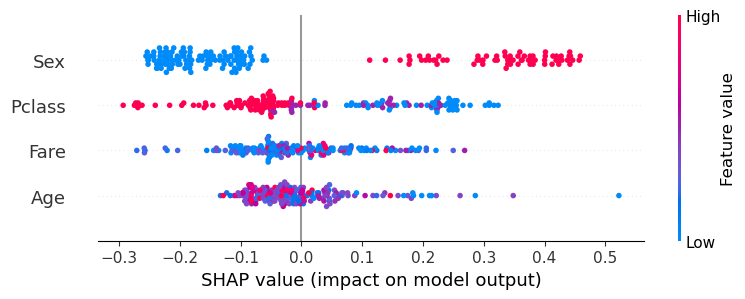

In [13]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

In [17]:
print(type(shap_values))
print(np.array(shap_values).shape)

print(explainer.expected_value)

<class 'shap._explanation.Explanation'>
(179, 4, 2)
[0.62570225 0.37429775]


In [18]:
import shap
print(shap.__version__)

0.52.0


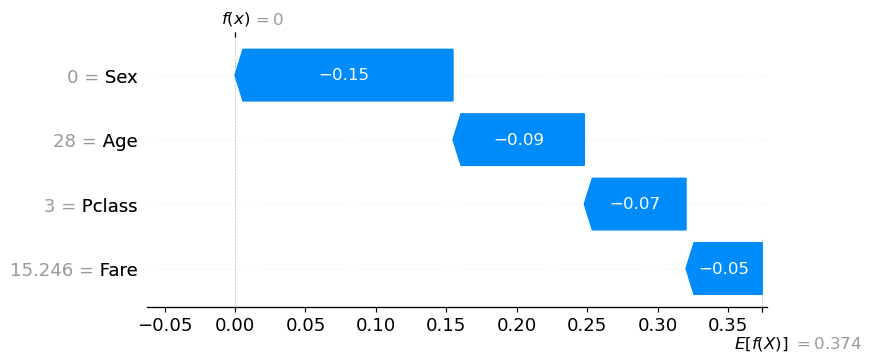

In [23]:
shap.plots.waterfall(shap_values[0, :, 1])

In [24]:
X_test_copy = X_test.copy()

X_test_copy['Actual'] = y_test

X_test_copy['Prediction'] = predictions

In [25]:
male = X_test_copy[X_test_copy['Sex']==0]

male_acc = (
    male['Actual']
    ==
    male['Prediction']
).mean()

print("Male Accuracy:", male_acc)

Male Accuracy: 0.8


In [26]:
female = X_test_copy[X_test_copy['Sex']==1]

female_acc = (
    female['Actual']
    ==
    female['Prediction']
).mean()

print("Female Accuracy:", female_acc)

Female Accuracy: 0.8115942028985508


## Mitigation Recommendations

1. Collect more balanced data.
2. Reduce dependence on sensitive attributes.
3. Conduct fairness testing regularly.
4. Monitor model performance after deployment.
5. Use fairness-aware machine learning algorithms.

### Conclusion

The model achieved good predictive performance. SHAP improved transparency by explaining predictions, while bias analysis highlighted fairness considerations that should be addressed before deployment.